In [1]:
import pandas as pd
import json
import pickle
import numpy as np

In [2]:
from ete3 import NCBITaxa
ncbi = NCBITaxa()

In [3]:
def info_dataframe(total_data):

    max=0
    
    min=np.inf

    len_total_data=total_data.shape[0] 
    print( f"nombre d'échantillon : {len_total_data}")
    print(f'nombre unique sequence : {len(total_data["sequence"].value_counts())}')
    for seq in total_data['sequence']:
        l=len(seq)
        if l>max:
            max=l
        if l<min:
            min=l


    print(f"taille max de séquence : {max}")
    print(f"taille min de sequence : {min}")

    
    print(f'nombre de genus : {len(total_data["genus"].value_counts())}')


    print(f'nombre de famille : {len(total_data["family"].value_counts())}')


    print(f'nombre de order : {len(total_data["order"].value_counts())}')


    
    print(f'nombre de class : {len(total_data["class"].value_counts())}')


    print(f'nombre de phylum : {len(total_data["phylum"].value_counts())}')


    print(f'nombre d"espèce : {len(total_data["species"].value_counts())}')

# 12S

In [4]:
data_12S_0 = pd.read_csv(r'D:\eDNA\data\data\Data12S\PretrainingData\RawData\12s_full.csv').drop(columns=['sub_sequences'])
data_12S_1 = pd.read_csv(r'C:\Users\Auguste Verdier\Desktop\TeleoClassification\data\crabs\12S\12S\output.tsv', sep='\t',header=None)


In [5]:
data_12S_1.head(2)

,0,1,2,3,4,5,6,7,8,9
0,LC552399.1.<1.>177,1001925,Eukaryota,Chordata,Actinopteri,Cypriniformes,Xenocyprididae,Nipponocypris,Nipponocypris_temminckii,CACCGCGGTTAAACGAGAGGCCCAAGTTGATAACACCACGGCGTAA...
1,LC340351.1.<1.>170,374848,Eukaryota,Chordata,Actinopteri,Salmoniformes,Salmonidae,Salvelinus,Salvelinus_curilus,CACCGCGGTTATACGAGAGGCCCTAGTTGATAACTACCGGCGTAAA...


In [6]:
data_12S_0.head(2)

,sequence,phylum,class,order,family,genus,species
0,GAACTACAAGTGAAAAACTTCAAACTTAAAGGACTTGACGGTATCC...,Chordata,Lepidosauria,Squamata,Lacertidae,Anatololacerta,Anatololacertadanfordi
1,GCCCCCGTGAGTAATGCCCTGACAGTTTTATATCCTAAAACGAGGA...,Chordata,Actinopteri,Scombriformes,Gempylidae,Promethichthys,Promethichthysprometheus


In [7]:
count_unique_sequence = data_12S_0['sequence'].nunique()
print(count_unique_sequence)
print(data_12S_0.shape)

145588
(206497, 7)


In [8]:
data_12S_0.drop_duplicates(subset=['sequence','genus'], keep='first', inplace=True)
print(data_12S_0.shape)

(145979, 7)


In [9]:
count_unique_sequence_2 = data_12S_1[9].nunique()
print(count_unique_sequence_2)
print(data_12S_1.shape)

171745
(326250, 10)


# 12 fish only

In [10]:
f_data_12S_0 = data_12S_0[(data_12S_0['class']  == 'Actinopteri') | (data_12S_0['class'] == 'Chondrichthyes')]
print(f_data_12S_0.shape)
print(f_data_12S_0['sequence'].nunique())
f_data_12S_0.drop_duplicates(subset=['sequence','genus'], keep='first', inplace=True)
print(f_data_12S_0.shape)

(26927, 7)
26774
(26927, 7)


C:\Users\Auguste Verdier\AppData\Local\Temp\ipykernel_8064\544718451.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  f_data_12S_0.drop_duplicates(subset=['sequence','genus'], keep='first', inplace=True)


In [11]:
f_data_12S_1 = data_12S_1[(data_12S_1[4]  == 'Actinopteri') | (data_12S_1[4] == 'Chondrichthyes')]
print(f_data_12S_1.shape)
print(f_data_12S_1[9].nunique())

(47595, 10)
30223


# Teleo

In [26]:
data_teleo_0 = pd.read_csv(r"D:\eDNA\data\data\Data12S\FinetuningData\RawData\full_dataset_teleo.csv")
data_teleo_1 = pd.read_csv(r"C:\Users\Auguste Verdier\Desktop\TeleoClassification\data\crabs_old\12S\teleo_12S_4.5\teleo_output.tsv", sep='\t',header=None)
data_teleo_2 = pd.read_csv(r"C:\Users\Auguste Verdier\Desktop\TeleoClassification\data\crabs_old\12S\teleo_12S_4.5\pga_4.5\teleo_pga_45_output.tsv", sep='\t',header=None)
data_teleo_3 = pd.read_csv(r"C:\Users\Auguste Verdier\Desktop\TeleoClassification\data\crabs_old\12S\teleo_12S_6\teleo_output.tsv", sep='\t',header=None)
data_teleo_4 = pd.read_csv(r"C:\Users\Auguste Verdier\Desktop\TeleoClassification\data\crabs_old\12S\teleo_12S_6\pga_6\teleo_pga_6_output.tsv", sep='\t',header=None)



data_teleo_1.rename(columns={0:'ID_ncbi', 1:'ID', 2:'kingdom', 3:'phylum', 4:'class', 5:'order', 6:'family', 7:'genus', 8:'species', 9:'sequence'}, inplace=True)
data_teleo_2.rename(columns={0:'ID_ncbi', 1:'ID', 2:'kingdom', 3:'phylum', 4:'class', 5:'order', 6:'family', 7:'genus', 8:'species', 9:'sequence'}, inplace=True)
data_teleo_3.rename(columns={0:'ID_ncbi', 1:'ID', 2:'kingdom', 3:'phylum', 4:'class', 5:'order', 6:'family', 7:'genus', 8:'species', 9:'sequence'}, inplace=True)
data_teleo_4.rename(columns={0:'ID_ncbi', 1:'ID', 2:'kingdom', 3:'phylum', 4:'class', 5:'order', 6:'family', 7:'genus', 8:'species', 9:'sequence'}, inplace=True)

In [18]:
info_dataframe(data_teleo_0)

nombre d'échantillon : 114567
nombre unique sequence : 18640
taille max de séquence : 808
taille min de sequence : 18
nombre de genus : 6480
nombre de famille : 1372
nombre de order : 258
nombre de class : 46
nombre de phylum : 16
nombre d"espèce : 17068


In [19]:
info_dataframe(data_teleo_1)

nombre d'échantillon : 118241
nombre unique sequence : 19124
taille max de séquence : 808
taille min de sequence : 18
nombre de genus : 6630
nombre de famille : 1392
nombre de order : 262
nombre de class : 46
nombre de phylum : 16
nombre d"espèce : 17568


In [20]:
info_dataframe(data_teleo_2)

nombre d'échantillon : 124127
nombre unique sequence : 20949
taille max de séquence : 808
taille min de sequence : 12
nombre de genus : 6668
nombre de famille : 1396
nombre de order : 263
nombre de class : 46
nombre de phylum : 16
nombre d"espèce : 18123


In [21]:
info_dataframe(data_teleo_3)

nombre d'échantillon : 142692
nombre unique sequence : 24475
taille max de séquence : 1925
taille min de sequence : 13
nombre de genus : 10717
nombre de famille : 2382
nombre de order : 481
nombre de class : 111
nombre de phylum : 39
nombre d"espèce : 26099


In [22]:
info_dataframe(data_teleo_4)

nombre d'échantillon : 184758
nombre unique sequence : 44964
taille max de séquence : 1925
taille min de sequence : 13
nombre de genus : 12234
nombre de famille : 2579
nombre de order : 521
nombre de class : 112
nombre de phylum : 39
nombre d"espèce : 32041


# 12S only fish

In [21]:
f_data_teleo_0 = data_teleo_0[(data_teleo_0['class'] == 'Actinopteri') | (data_teleo_0['class'] == 'Chondrichthyes')]
f_data_teleo_1 = data_teleo_1[(data_teleo_1['class'] == 'Actinopteri') | (data_teleo_1['class'] == 'Chondrichthyes')]
f_data_teleo_2 = data_teleo_2[(data_teleo_2['class'] == 'Actinopteri') | (data_teleo_2['class'] == 'Chondrichthyes')]
f_data_teleo_3 = data_teleo_3[(data_teleo_3['class'] == 'Actinopteri') | (data_teleo_3['class'] == 'Chondrichthyes')]
f_data_teleo_4 = data_teleo_4[(data_teleo_4['class'] == 'Actinopteri') | (data_teleo_4['class'] == 'Chondrichthyes')]

In [22]:
info_dataframe(f_data_teleo_0)

nombre d'échantillon : 18687
nombre unique sequence : 7470
taille max de séquence : 129
taille min de sequence : 25
nombre de genus : 2728
nombre de famille : 499
nombre de order : 81
nombre de class : 2
nombre de phylum : 1
nombre d"espèce : 7425


In [23]:
info_dataframe(f_data_teleo_1)

nombre d'échantillon : 19810
nombre unique sequence : 7692
taille max de séquence : 129
taille min de sequence : 25
nombre de genus : 2768
nombre de famille : 503
nombre de order : 81
nombre de class : 2
nombre de phylum : 1
nombre d"espèce : 7647


In [24]:
info_dataframe(f_data_teleo_2)

nombre d'échantillon : 23226
nombre unique sequence : 8495
taille max de séquence : 129
taille min de sequence : 19
nombre de genus : 2783
nombre de famille : 504
nombre de order : 81
nombre de class : 2
nombre de phylum : 1
nombre d"espèce : 7981


In [25]:
info_dataframe(f_data_teleo_3)

nombre d'échantillon : 19869
nombre unique sequence : 7734
taille max de séquence : 663
taille min de sequence : 25
nombre de genus : 2771
nombre de famille : 503
nombre de order : 81
nombre de class : 2
nombre de phylum : 1
nombre d"espèce : 7666


In [26]:
info_dataframe(f_data_teleo_4)

nombre d'échantillon : 36883
nombre unique sequence : 15920
taille max de séquence : 663
taille min de sequence : 25
nombre de genus : 3249
nombre de famille : 528
nombre de order : 81
nombre de class : 2
nombre de phylum : 1
nombre d"espèce : 10305


In [72]:
f_data_teleo_4["ID"].nunique()

10471

In [28]:
unique_sequences = f_data_teleo_4[~f_data_teleo_4['sequence'].isin(f_data_teleo_0['sequence']) &
                                ~f_data_teleo_4['sequence'].isin(f_data_teleo_1['sequence']) &
                                ~f_data_teleo_4['sequence'].isin(f_data_teleo_2['sequence']) &
                                ~f_data_teleo_4['sequence'].isin(f_data_teleo_3['sequence'])]

unique_sequences = unique_sequences.drop_duplicates(subset='sequence', keep='first')
info_dataframe(unique_sequences)

nombre d'échantillon : 7533
nombre unique sequence : 7533
taille max de séquence : 479
taille min de sequence : 63
nombre de genus : 2096
nombre de famille : 450
nombre de order : 79
nombre de class : 2
nombre de phylum : 1
nombre d"espèce : 5066


In [51]:
unique_sequences.to_csv(r"C:\Users\Auguste Verdier\Desktop\TeleoClassification\data\crabs\12S\teleo_12S_6\pga_6\unique_sequences.csv", sep='\t', index=False, header=True)

In [52]:
unique_sequences = f_data_teleo_0[~f_data_teleo_0['sequence'].isin(f_data_teleo_4['sequence'])]
print(unique_sequences["sequence"].unique())

['CCCCAAACTAGCCAAATTCATTTAAATAAAAACTTATTATAGTAAAGGGGAGGCAAGTCGTAA'
 'CTCCAAGCCTACTATTCTCAATAACTAATATAACACCAACTGCAAAGGAGAGGCAAGTCGTAA'
 'CCTCAAGTACCAGGATGCGTACTACCAACCATATTGCTATAACGCACAGACATATGAGAGGAGATAAGTCGTAA'
 'CCCCAAGCTTAAATAAAAAANTTTATAATAACCTAAAAANGCAAAGGGGAGGCAAGTCGTAA']


# Fish Base

In [36]:
data_teleo_fb = pd.read_csv(r"C:\Users\Auguste Verdier\Desktop\TeleoClassification\data\crabs\fish_base\teleo_fb_45_output.tsv", sep='\t',header=None)
data_teleo_fb.rename(columns={0:'ID_ncbi', 1:'ID', 2:'kingdom', 3:'phylum', 4:'class', 5:'order', 6:'family', 7:'genus', 8:'species', 9:'sequence'}, inplace=True)
data_teleo_fb.sample(2)


fb_12S = pd.read_csv(r"C:\Users\Auguste Verdier\Desktop\TeleoClassification\data\crabs\fish_base\output.tsv", sep='\t',header=None)
fb_12S.rename(columns={0:'ID_ncbi', 1:'ID', 2:'kingdom', 3:'phylum', 4:'class', 5:'order', 6:'family', 7:'genus', 8:'species', 9:'sequence'}, inplace=True)
print(fb_12S.shape)

(869295, 10)


In [37]:
info_dataframe(fb_12S)

nombre d'échantillon : 869295
nombre unique sequence : 537425
taille max de séquence : 25498
taille min de sequence : 25
nombre de genus : 4560
nombre de famille : 565
nombre de order : 86
nombre de class : 5
nombre de phylum : 1
nombre d"espèce : 44246


In [74]:
info_dataframe(data_teleo_fb)

nombre d'échantillon : 21834
nombre unique sequence : 8396
taille max de séquence : 129
taille min de sequence : 13
nombre de genus : 2857
nombre de famille : 516
nombre de order : 86
nombre de class : 5
nombre de phylum : 1
nombre d"espèce : 8516


In [75]:
data_teleo_fb.sample(2)

,ID_ncbi,ID,kingdom,phylum,class,order,family,genus,species,sequence
3601,MH301078,8167,Eukaryota,Chordata,Actinopteri,Perciformes,Percidae,Perca,Perca_flavescens,CCCCAAGCCTACCAACTAAAATAATTAAAACCCTATAATTGCGAAG...
11923,EF100186,7781,Eukaryota,Chordata,Chondrichthyes,Rajiformes,Rajidae,Raja,Raja_clavata,CCTCAACTTACATCACTCCATTTTATAAATAACTTTTTATCACAAG...


In [77]:
f_data_teleo_0[f_data_teleo_0['genus'] == "Gadus"]['species']

,sequence,phylum,class,order,family,genus,species
4498,CTCCAAATAAACCCTAGATATTACCTAAAATGCTTTTTATAATAAG...,Chordata,Actinopteri,Gadiformes,Gadidae,Gadus,Gadusogac
6737,CTCCAAATAAACCCTAGATATTACCTAAAATGCTTTTTATAATAAG...,Chordata,Actinopteri,Gadiformes,Gadidae,Gadus,Gadusmacrocephalus
7154,CTCCAAATAAACCCTAGATATTACCTAAAATGCTTTTTATAATAAG...,Chordata,Actinopteri,Gadiformes,Gadidae,Gadus,Gadusmorhua
7155,CTCCAAATAAACCCTAGATATTACCTAAAATGCTTTTTATAATAAG...,Chordata,Actinopteri,Gadiformes,Gadidae,Gadus,Gadusmorhua
7156,CTCCAAATAAACCCTAGATATTACCTAAAATGCTTTTTATAATAAG...,Chordata,Actinopteri,Gadiformes,Gadidae,Gadus,Gadusmorhua
...,...,...,...,...,...,...,...
35755,CTCCAAATAAACCCTAGATATTACCTAAAATGCTTTTTATAATAAG...,Chordata,Actinopteri,Gadiformes,Gadidae,Gadus,Gadusmorhua
35792,CTCCAAATAAACCCTAGATATTACCTAAAATGCTTTTTATAATAAG...,Chordata,Actinopteri,Gadiformes,Gadidae,Gadus,Gadusmorhua
36026,CTCCAAATAAACCCTAGATATTACCTAAAATGCTTTTTATAATAAG...,Chordata,Actinopteri,Gadiformes,Gadidae,Gadus,Gadusmorhua
36365,CTCCAAATAAACCCTAGATATTACCTAAAATGCTTTTTATAATAAG...,Chordata,Actinopteri,Gadiformes,Gadidae,Gadus,Gaduschalcogrammus


In [33]:
f_data_teleo_fb=data_teleo_fb[(data_teleo_fb['class'] == 'Actinopteri') | (data_teleo_fb['class'] == 'Chondrichthyes')]
f_data_teleo_fb

,ID_ncbi,ID,kingdom,phylum,class,order,family,genus,species,sequence
0,KY213961,270547,Eukaryota,Chordata,Actinopteri,NaN,Centropomidae,Lates,Lates_japonicus,CCCCGAGCACCCGGCATAACATAAATAAAACCAAACGAACGCGAAG...
1,KY213962,8187,Eukaryota,Chordata,Actinopteri,NaN,Centropomidae,Lates,Lates_calcarifer,CCCCATAGCACCCGGCTAAAACATAAATAAAGCACAAACGAACGCT...
2,KY213963,29147,Eukaryota,Chordata,Actinopteri,NaN,Centropomidae,Lates,Lates_niloticus,CCCCAAGCACCCGGCATAATATACATAAAACCAAACGAACGCGAAG...
3,KY213964,329030,Eukaryota,Chordata,Actinopteri,NaN,Centropomidae,Psammoperca,Psammoperca_waigiensis,CCCCAAGACAGTAAAACGCAAGTAACTAAACCCAAACACAACACCA...
4,KY228977,1001936,Eukaryota,Chordata,Actinopteri,Cypriniformes,Gobionidae,Microphysogobio,Microphysogobio_amurensis,CCCCTGTCAACACGCATTATAAATACATAATATCAAAGCACTGACA...
...,...,...,...,...,...,...,...,...,...,...
21829,PP533446,192602,Eukaryota,Chordata,Actinopteri,Carangiformes,Carangidae,Trachurus,Trachurus_murphyi,CCCCAAGCTCCTGGACCCTAATCCTACTTAAACCGTAACAAATGCG...
21830,PP739582,1604517,Eukaryota,Chordata,Actinopteri,Gobiiformes,Gobiidae,Gymnogobius,Gymnogobius_scrobiculatus,CCCCAAGATAAAGACCAAATGTAAATAAGACTAAACTTACAAAAAG...
21831,OQ581844,1812872,Eukaryota,Chordata,Actinopteri,Anguilliformes,Synaphobranchidae,Synaphobranchus,Synaphobranchus_brevidorsalis,CCTCGAATAAATTCAAAACATCTATAAGCACTAAAACACAAGAAAG...
21832,PQ182885,240697,Eukaryota,Chordata,Actinopteri,Syngnathiformes,Syngnathidae,Syngnathus,Syngnathus_temminckii,CCCCTAATGTCTCATAGAATTAAGTAAAACACCTGAAAAATTAAGG...


In [77]:
unique_sequences = f_data_teleo_fb[~f_data_teleo_fb['sequence'].isin(f_data_teleo_0['sequence'])]# &
                                # ~data_teleo_fb['sequence'].isin(f_data_teleo_1['sequence']) &
                                # ~data_teleo_fb['sequence'].isin(f_data_teleo_2['sequence']) &
                                # ~data_teleo_fb['sequence'].isin(f_data_teleo_3['sequence']) &
                                # ~data_teleo_fb['sequence'].isin(f_data_teleo_4['sequence'])]
print(unique_sequences["sequence"].nunique())

unique_sequences = unique_sequences.drop_duplicates(subset='sequence', keep='first')
print(unique_sequences.shape)
unique_sequences.to_csv(r"C:\Users\Auguste Verdier\Desktop\TeleoClassification\data\crabs\fish_base\unique_sequences.csv", sep='\t', index=False, header=True)

971
(971, 10)


# Total Teleo

In [53]:
total_teleo = pd.concat([f_data_teleo_0,    f_data_teleo_1, f_data_teleo_fb]) # f_data_teleo_4,f_data_teleo_2,
info_dataframe(total_teleo)
drop_duplicates = total_teleo.drop_duplicates( keep='first')
print(drop_duplicates.shape)
drop_duplicates_genus = total_teleo.drop_duplicates(subset=['genus','sequence'], keep='first')
print(drop_duplicates_genus.shape)

nombre d'échantillon : 60041
nombre unique sequence : 8445
taille max de séquence : 129
taille min de sequence : 13
nombre de genus : 2864
nombre de famille : 509
nombre de order : 81
nombre de class : 2
nombre de phylum : 1
nombre d"espèce : 15989
(50482, 10)
(8938, 10)


In [54]:
f_data_teleo_0
info_dataframe(f_data_teleo_0)
print(f_data_teleo_0.shape)
print(f_data_teleo_0["sequence"].nunique())
drop_duplicates = f_data_teleo_0.drop_duplicates( keep='first')
print(drop_duplicates.shape)
drop_duplicates_genus = f_data_teleo_0.drop_duplicates(subset=['genus','sequence'], keep='first')
print(drop_duplicates_genus.shape)

nombre d'échantillon : 18687
nombre unique sequence : 7470
taille max de séquence : 129
taille min de sequence : 25
nombre de genus : 2728
nombre de famille : 499
nombre de order : 81
nombre de class : 2
nombre de phylum : 1
nombre d"espèce : 7425
(18687, 7)
7470
(9128, 7)
(7814, 7)


# error 3 teleo 

In [29]:
teleo_12S= pd.read_csv(r"C:\Users\Auguste Verdier\Desktop\TeleoClassification\data\crabs_old\12S\teleo_12S_3\output_pga_3.tsv", sep='\t',header=None)
teleo_12S.rename(columns={0:'ID_ncbi', 1:'ID', 2:'kingdom', 3:'phylum', 4:'class', 5:'order', 6:'family', 7:'genus', 8:'species', 9:'sequence'}, inplace=True)
teleo_12S.sample(2)

,ID_ncbi,ID,kingdom,phylum,class,order,family,genus,species,sequence
58535,KT725902.1.646.1599,9606,Eukaryota,Chordata,Mammalia,Primates,Hominidae,Homo,Homo_sapiens,CCTCAAGTATACTTCAAAGGACATTTAACTAAAACCCCTACGCATT...
17661,KP259808.1.1214.2178,30408,Eukaryota,Chordata,Aves,Galliformes,Phasianidae,Crossoptilon,Crossoptilon_crossoptilon,CTTCATAGGCCCCAATATTAATAAATAATACCTGCATCTAAGCCAA...


In [31]:
teleo_fb = pd.read_csv(r"C:\Users\Auguste Verdier\Desktop\TeleoClassification\data\crabs_old\mitofish\teleo_fb_3\output_pga_3.tsv", sep='\t',header=None)
teleo_fb.rename(columns={0:'ID_ncbi', 1:'ID', 2:'kingdom', 3:'phylum', 4:'class', 5:'order', 6:'family', 7:'genus', 8:'species', 9:'sequence'}, inplace=True)
teleo_fb.sample(2)

,ID_ncbi,ID,kingdom,phylum,class,order,family,genus,species,sequence
8328,JQ661483,59861,Eukaryota,Chordata,Actinopteri,Salmoniformes,Salmonidae,Coregonus,Coregonus_clupeaformis,CCCCAAGTTCAATCTACCCTTCTAACTAAGAAGTTAACCGAACAAA...
12079,EU552663,224713,Eukaryota,Chordata,Actinopteri,Clupeiformes,Clupeidae,Dorosoma,Dorosoma_petenense,CCCCAACAACACCCACATCTGATAACTAACAAAACAGCAGCTACAA...


In [32]:
info_dataframe(teleo_12S)

nombre d'échantillon : 117261
nombre unique sequence : 18624
taille max de séquence : 139
taille min de sequence : 12
nombre de genus : 5361
nombre de famille : 1071
nombre de order : 201
nombre de class : 30
nombre de phylum : 11
nombre d"espèce : 15562


In [33]:
info_dataframe(teleo_fb)

nombre d'échantillon : 25513
nombre unique sequence : 9237
taille max de séquence : 129
taille min de sequence : 11
nombre de genus : 2862
nombre de famille : 515
nombre de order : 85
nombre de class : 5
nombre de phylum : 1
nombre d"espèce : 8901


In [34]:
teleo_fb['class'].unique()

array(['Actinopteri', 'Chondrichthyes', 'Hyperoartia', 'Myxini', nan,
       'Cladistia'], dtype=object)

In [35]:
fish_12S_teleo = teleo_12S[teleo_12S['class'].isin(teleo_fb['class'].unique())]
info_dataframe(fish_12S_teleo)

nombre d'échantillon : 23990
nombre unique sequence : 8734
taille max de séquence : 129
taille min de sequence : 19
nombre de genus : 2869
nombre de famille : 528
nombre de order : 88
nombre de class : 5
nombre de phylum : 2
nombre d"espèce : 8191


In [36]:
all_teleo = pd.concat([fish_12S_teleo, teleo_fb])
teleo_nan = all_teleo[all_teleo['class'].isna()]


In [37]:
info_dataframe(all_teleo)

nombre d'échantillon : 49503
nombre unique sequence : 9564
taille max de séquence : 129
taille min de sequence : 11
nombre de genus : 2961
nombre de famille : 533
nombre de order : 88
nombre de class : 5
nombre de phylum : 2
nombre d"espèce : 9192


In [32]:
teleo_nan = all_teleo[all_teleo['class'].isna()]
teleo_nan.to_csv(r"C:\Users\Auguste Verdier\Desktop\TeleoClassification\data\crabs_old\mitofish\fish_base\teleo_nan.csv", sep=',', index=False, header=True)


- Coelacanthiformes -> Sarcopterygii
- Testudines -> no
- Crocodylia -> no
- Ceratodontiformes -> Sarcopterygii
- KM078797 -> no
- diplora -> no
- AB626856 -> Eukaryota,Chordata,Actinopteri,Cypriniformes,Leuciscidae,Pseudaspius,Pseudaspius_sachalinensis,
- AP011270 -> Eukaryota,Chordata,Actinopteri,Cypriniformes,Leuciscidae,Pseudaspius,Pseudaspius_sachalinensis,


In [38]:
nan_correction = pd.read_csv(r"C:\Users\Auguste Verdier\Desktop\TeleoClassification\data\crabs_old\mitofish\teleo_nan.csv", sep=',')
nan_correction.sample(2)

,ID_ncbi,ID,kingdom,phylum,class,order,family,genus,species,sequence
38,MF489917.1.69.1020,7892,Eukaryota,Chordata,Sarcopterygii,Ceratodontiformes,Ceratodontidae,Neoceratodus,Neoceratodus_forsteri,CCTCAATAACAATCTAAACAGTAAATAACTAAACATAATTAAAATA...
62,HM235679.1.<1.>930,685507,Eukaryota,Chordata,Sarcopterygii,Ceratodontiformes,Protopteridae,Protopterus,Protopterus_aethiopicus,CCTCAACAATCGTAAACGATAAATAATTAATTTAGATAAAAAAGAG...


In [39]:
nan_correction['class'].unique()

array(['Sarcopterygii', 'Actinopteri'], dtype=object)

In [40]:
cleaned_teleo = pd.concat([all_teleo.dropna(subset=['class']), nan_correction])
info_dataframe(cleaned_teleo)

nombre d'échantillon : 48901
nombre unique sequence : 9351
taille max de séquence : 129
taille min de sequence : 11
nombre de genus : 2880
nombre de famille : 516
nombre de order : 85
nombre de class : 6
nombre de phylum : 1
nombre d"espèce : 9001


In [41]:
cleaned_teleo['class'].value_counts()
print(cleaned_teleo['sequence'].nunique())
print(len(cleaned_teleo))
cleaned_teleo_correct_len = cleaned_teleo[cleaned_teleo['sequence'].str.len() >= 20]


cleaned_teleo_no_N = cleaned_teleo_correct_len[cleaned_teleo_correct_len['sequence'].str.contains('N') == False]


print(len(cleaned_teleo_no_N))

print(cleaned_teleo_no_N['sequence'].nunique())

9351
48901
48668
9278


In [42]:

cleaned_teleo_no_N.to_csv(r"C:\Users\Auguste Verdier\Desktop\TeleoClassification\data\crabs\teleo_fb_gb_clean_N_len_class.csv", sep=',', index=False, header=True)

# Clean nan

In [42]:
dic_family_to_order = {"Scatophagidae": 'Perciformes',
                       'Sillaginidae' : 'Perciformes',
                       'Plesiopidae'  : 'Perciformes',
                       'Pomacanthidae' : 'Perciformes',
                       "Sciaenidae": "Acanthuriformes",
                        "Ambassidae"  : "Perciformes",
                        "Pseudochromidae"  : "Perciformes",
                        "Polycentridae" : "Perciformes",
                        "Opistognathidae"  : "Perciformes",
                         "Toxotidae" : "Perciformes",
                         'Pristiophoridae' : 'Pristiophoriformes',
                         'Platyrhinidae' : 'Torpediniformes',
                         'Emmelichthyidae' : 'Acanthuriformes',
                         'Pomacentridae':  "Perciformes",
                         'Embiotocidae' :'Perciformes',
                         'Siganidae': 'Perciformes',
                         'Squatinidae' : 'Squatiniformes',
                         "Centropomidae" : "Perciformes" ,
                        "Malacanthidae" : "Perciformes" ,
                        'Polynemidae' :  'Perciformes' , 
                        'Moronidae' :  'Perciformes' ,
                        'Menidae' :  'Perciformes' ,
                        "Lactariidae" : "Perciformes",
                        "Sphyraenidae" : "Perciformes",
                        'Callanthiidae' : 'Perciformes',
                        "Monodactylidae" : "Perciformes"}

dic_order_to_class = {'Coelacanthiformes': "Sarcopterygii",
                        'Ceratodontiformes' : 'Sarcopterygii'}

dic_genus_to_family = {'Percalates': 'Percichthyidae',
                       'Paedocypris': 'Cyprinidae',
                       'Bembrops' : 'Percophidae',
                       'Conorhynchos' : 'Pimelodidae',
                       'Lepidogalaxias' :'Lepidogalaxiidae',
                       }
def fill_nan(total_data):
    total_data = total_data.copy()
    for key,item in dic_family_to_order.items():
        idx = total_data[total_data['family']==key]
        total_data.loc[idx.index, 'order'] = item
    for key,item in dic_order_to_class.items():
        idx = total_data[total_data['order']==key]
        total_data.loc[idx.index, 'class'] = item
    for key,item in dic_genus_to_family.items():
        idx = total_data[total_data['genus']==key]
        total_data.loc[idx.index, 'family'] = item

    
    total_data =total_data.dropna()
    
    

    return total_data

In [43]:
# teleo = pd.read_csv(r"C:\Users\Auguste Verdier\Desktop\TeleoClassification\data\crabs\teleo_fb_gb_clean_N_len_class.csv", sep=',')
teleo = fill_nan(cleaned_teleo_no_N)
info_dataframe(teleo)
teleo.to_csv(r"C:\Users\Auguste Verdier\Desktop\TeleoClassification\data\crabs\teleo_final.csv", sep=',', index=False, header=True)

nombre d'échantillon : 48524
nombre unique sequence : 9267
taille max de séquence : 129
taille min de sequence : 20
nombre de genus : 2871
nombre de famille : 516
nombre de order : 87
nombre de class : 6
nombre de phylum : 1
nombre d"espèce : 8914


In [44]:
teleo[teleo['species'].isna()]

,ID_ncbi,ID,kingdom,phylum,class,order,family,genus,species,sequence


In [27]:
teleo.to_csv(r"C:\Users\Auguste Verdier\Desktop\TeleoClassification\data\crabs\teleo_fb_gb_order_clean.csv")

In [45]:
teleo['class'].value_counts()

class
Actinopteri       42574
Chondrichthyes     5185
Sarcopterygii       424
Cladistia           222
Hyperoartia         103
Myxini               16
Name: count, dtype: int64

In [46]:
teleo_class_A_C = teleo[~(teleo['class'] == 'Actinopteri') & ~(teleo['class'] == 'Chondrichthyes')]
teleo_class_A_C = teleo[(teleo['class'] == 'Actinopteri') | (teleo['class'] == 'Chondrichthyes')]
info_dataframe(teleo_class_A_C)

nombre d'échantillon : 47759
nombre unique sequence : 9203
taille max de séquence : 129
taille min de sequence : 20
nombre de genus : 2854
nombre de famille : 508
nombre de order : 82
nombre de class : 2
nombre de phylum : 1
nombre d"espèce : 8861


In [82]:
teleo_class_A_C.to_csv(r"C:\Users\Auguste Verdier\Desktop\TeleoClassification\data\teleo_class_A_C.csv", sep=',', index=False, header=True)


In [50]:
data= pd.read_csv(r"C:\Users\Auguste Verdier\Desktop\TeleoClassification\data\teleo_class_A_C.csv")
data_2 = pd.read_csv(r"C:\Users\Auguste Verdier\Desktop\TeleoClassification\data\teleo_class_A_C_bis.tsv", sep='\t')

# info_dataframe(data)

# info_dataframe(data_2)
print(data['order'].value_counts())
print(data_2['order'].value_counts())
# data_no_in_data2 = data[~data['sequence'].isin(data_2['sequence'])]


order
Cypriniformes          7713
Perciformes            6004
Gobiiformes            3064
Siluriformes           2706
Carcharhiniformes      2335
                       ... 
Amiiformes                6
Hiodontiformes            6
Stylephoriformes          4
Echinorhiniformes         2
Lepidogalaxiiformes       2
Name: count, Length: 82, dtype: int64
order
Cypriniformes          7523
Perciformes            6766
Gobiiformes            2993
Siluriformes           2667
Carcharhiniformes      2306
                       ... 
Amiiformes                6
Hiodontiformes            6
Stylephoriformes          4
Echinorhiniformes         2
Lepidogalaxiiformes       2
Name: count, Length: 82, dtype: int64


# Split data fold


In [47]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, KFold
import math
import json


# data = pd.read_csv(r"C:\Users\Auguste Verdier\Desktop\TeleoClassification\data\teleo_class_A_C.csv")


def create_k_folds(total_data, n_splits=6):
    total_data = total_data.copy()
    for k in range(n_splits):
        # fill the fold column with -1
        total_data[f'fold_{k}'] = "none"
    

    families = total_data['family'].unique()

    for family in families:

        family_data = total_data[total_data['family'] == family]
        genus_labels = family_data['genus'].unique()
        genus_number = family_data['genus'].nunique()

        if genus_number ==1:
            
            # exclude family with only one genus
            continue

        elif genus_number < n_splits :
            skf = KFold(n_splits=genus_number)
            
        else :
            skf = KFold(n_splits=n_splits)
        


        random_fold_assigment = np.arange(min(genus_number, n_splits))
        np.random.shuffle(random_fold_assigment)
       
        for fold, (train_index, val_index) in enumerate(skf.split(genus_labels)):

           

            val_genus = genus_labels[val_index]
            train_genus = genus_labels[train_index]
           
            val_data = total_data[total_data['genus'].isin(val_genus)]

            if len(val_data)>1:
                # if there are more than 1 sample in the validation set, 50/50 split it into validation and test
                val_index , test_index = train_test_split(val_data.index, test_size=0.5, random_state=42) #  stratify=total_data.iloc[val_index]['family'],
            else:
                # if there is only one sample in the validation set, use it as test
                val_index = []
                test_index = val_data.index
            # print(val_index)
            
            total_data.loc[val_index, f'fold_{random_fold_assigment[fold]}'] = 'val'
            # print('fold : ',fold)
            # print('val',pd.concat([total_data.loc[val_index],total_data.loc[test_index]])['genus'].nunique())

            total_data.loc[test_index, f'fold_{random_fold_assigment[fold]}'] = 'test'
     

            total_data.loc[total_data['genus'].isin(train_genus), f'fold_{random_fold_assigment[fold]}'] = 'train'

        #     print('train',total_data.loc[family_data.index[train_index]]['genus'].nunique())
        

        if fold < n_splits-1:
            
            a=np.arange(fold+1)
            np.random.shuffle(a)
            dulicate = np.tile(a, math.ceil((n_splits-fold-1)/(fold+1)))[:n_splits-fold-1]
            for i,f in enumerate(range(fold + 1, n_splits)):

                total_data.loc[family_data.index, f'fold_{f}'] = total_data.loc[family_data.index, f'fold_{dulicate[i]}'].copy()
        
    
    return total_data



In [48]:
total_data_with_folds = create_k_folds(teleo_class_A_C)

In [49]:
total_data_with_folds.sample(2)
len(total_data_with_folds)

47759

In [50]:
total_data_with_folds['fold_2'].value_counts()

fold_2
train    36463
test      4731
val       4587
none      1978
Name: count, dtype: int64

In [56]:
kold =3
val =total_data_with_folds[total_data_with_folds[f'fold_{kold}'] == 'val']
train =total_data_with_folds[total_data_with_folds[f'fold_{kold}'] == 'train']
test =total_data_with_folds[total_data_with_folds[f'fold_{kold}'] == 'test']
val_test = pd.concat([val,test])

print(train['genus'].nunique() / (train['genus'].nunique() + val_test['genus'].nunique() ))
assert set(val_test['genus']).isdisjoint(set(train['genus']))
# print(total_data_with_folds.shape[0], val.shape[0] + train.shape[0] + test.shape[0])
print((val.shape[0] + test.shape[0]) /(val.shape[0] + train.shape[0] + test.shape[0]))
print(train.shape[0] /(val.shape[0] + train.shape[0] + test.shape[0]))

0.6202783300198808


AssertionError: 

In [103]:
total_data_with_folds.to_csv(r"C:\Users\Auguste Verdier\Desktop\TeleoClassification\data\crabs\teleo_final_with_folds_clean.csv", sep=',', index=False, header=True)

# save fold

In [106]:
import pandas as pd
import os
import json

total_data_with_folds = pd.read_csv(r"C:\Users\Auguste Verdier\Desktop\TeleoClassification\data\crabs\teleo_final_with_folds_clean.csv")
total_data = total_data_with_folds.drop_duplicates(subset=['sequence','genus'], keep='first')
total_data.to_csv(r"C:\Users\Auguste Verdier\Desktop\TeleoClassification\data\crabs\teleo_final_with_folds_clean_dedup.csv", sep=',', index=False, header=True)
os.makedirs(f"C:/Users/Auguste Verdier/Desktop/TeleoClassification/data/teleo_clean", exist_ok=True)
for fold in range(6):
    os.makedirs(f"C:/Users/Auguste Verdier/Desktop/TeleoClassification/data/teleo_clean", exist_ok=True)
    os.makedirs(f"C:/Users/Auguste Verdier/Desktop/TeleoClassification/data/teleo_clean/fold_{fold+1}", exist_ok=True)

    train = total_data_with_folds[total_data_with_folds[f'fold_{fold}'] == 'train']
    val = total_data_with_folds[total_data_with_folds[f'fold_{fold}'] == 'val']
    # [['sequence','order','family']].drop_duplicates(subset=['family'], keep='first')
    test = total_data_with_folds[total_data_with_folds[f'fold_{fold}'] == 'test']
    # [['sequence','order','family']].drop_duplicates(subset=['family'], keep='first')
    json_data = pd.concat([val,test])['genus'].unique().tolist()
    json.dump(json_data, open(rf"C:\Users\Auguste Verdier\Desktop\TeleoClassification\data\teleo_clean\fold_{fold+1}\test_genus.json", 'w'))
    
    train = train.drop_duplicates(subset=['sequence','family'], keep='first')
    val = val.drop_duplicates(subset=['sequence','family'], keep='first')
    test = test.drop_duplicates(subset=['sequence','family'], keep='first')

    val[['sequence', 'order' , 'family', 'genus','species']].to_csv(rf"C:\Users\Auguste Verdier\Desktop\TeleoClassification\data\teleo_clean\fold_{fold+1}\val.csv", sep=',', index=False, header=True)
    train[['sequence', 'order' , 'family', 'genus', 'species']].to_csv(rf"C:\Users\Auguste Verdier\Desktop\TeleoClassification\data\teleo_clean\fold_{fold+1}\train.csv", sep=',', index=False, header=True)
    test[['sequence', 'order' , 'family', 'genus', 'species']].to_csv(rf"C:/Users/Auguste Verdier\Desktop/TeleoClassification\data\teleo_clean\fold_{fold+1}\test.csv", sep=',', index=False, header=True)
    
    json_data = pd.concat([val,test])
    # val.to_csv(rf"C:\Users\Auguste Verdier\Desktop\TeleoClassification\data\fold_{fold+1}\val.csv", sep=',', index=False, header=True)
    # train.to_csv(rf"C:\Users\Auguste Verdier\Desktop\TeleoClassification\data\fold_{fold+1}\train.csv", sep=',', index=False, header=True)
    # test.to_csv(rf"C:/Users\Auguste Verdier\Desktop\TeleoClassification\data\fold_{fold+1}\test.csv", sep=',', index=False, header=True)

In [2]:
import pandas as pd
okok_data= pd.read_csv(r"C:\Users\Auguste Verdier\Desktop\TeleoClassification\data\teleo_class_A_C.csv")
new_data = pd.read_csv(r"C:\Users\Auguste Verdier\Desktop\TeleoClassification\data\v2024_Teleo_BEV_RBDD_complete.csv")

no_dupl_data = okok_data.drop_duplicates(subset=['sequence','genus'], keep='first')




In [3]:

# Create tuples of (marker, genus) from new_data
new_data_tuples = set(new_data[['marker', 'genus']].apply(tuple, axis=1))

print( len (new_data_tuples))
# Create tuples of (sequence, genus) from no_dupl_data
old_data_tuples = set(no_dupl_data[['sequence', 'genus']].apply(tuple, axis=1))

# Check how many (marker, genus) tuples are in (sequence, genus) tuples
in_old = new_data_tuples.intersection(old_data_tuples)
not_in_old = new_data_tuples.difference(old_data_tuples)

print(f"Number of (marker, genus) tuples in (sequence, genus) tuples: {len(in_old)}")
print(f"Number of (marker, genus) tuples not in (sequence, genus) tuples: {len(not_in_old)}")

1393
Number of (marker, genus) tuples in (sequence, genus) tuples: 747
Number of (marker, genus) tuples not in (sequence, genus) tuples: 646


# Precess PCR

In [4]:
from pre_process import pre_process, info_dataframe, pre_process_mifish
import pandas as pd
import numpy as np

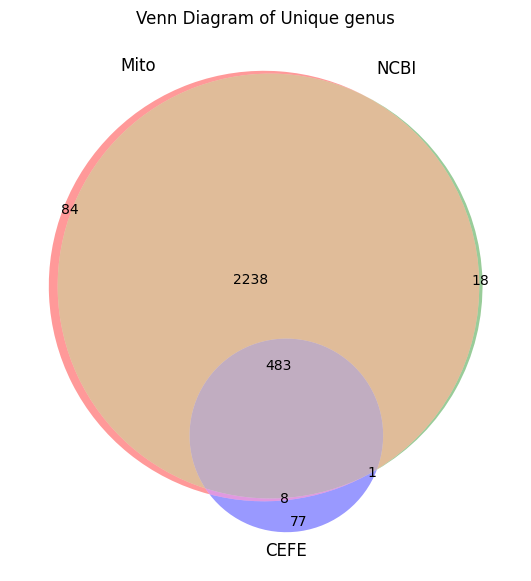

In [11]:
from matplotlib_venn import venn3

mito= pd.read_csv(r"C:\Users\Auguste Verdier\Desktop\TeleoClassification\data\crabs\mitofish\teleo_fb_3\output_teleo_3.tsv", sep='\t',header=None)
ncbi = pd.read_csv(r"C:\Users\Auguste Verdier\Desktop\TeleoClassification\data\crabs\12S\teleo_12S_3\output_pcr_3.tsv", sep='\t',header=None)
mito.rename(columns={0:'ID_ncbi', 1:'ID', 2:'kingdom', 3:'phylum', 4:'class', 5:'order', 6:'family', 7:'genus', 8:'species', 9:'sequence'}, inplace=True)
ncbi.rename(columns={0:'ID_ncbi', 1:'ID', 2:'kingdom', 3:'phylum', 4:'class', 5:'order', 6:'family', 7:'genus', 8:'species', 9:'sequence'}, inplace=True)
cefe= pd.read_csv(r"C:\Users\Auguste Verdier\Desktop\TeleoClassification\data\v2024_Teleo_BEV_RBDD_complete.csv")
only_class= ['Actinopteri', 'Chondrichthyes']

mito = mito[mito['class'].isin(only_class)]
ncbi = ncbi[ncbi['class'].isin(only_class)]
cefe = cefe[cefe['class'].isin(only_class)]

cefe.head(2)


import matplotlib.pyplot as plt

rank = 'genus'
# Get unique species from each dataframe
species_mito = set(mito[rank].unique())
species_ncbi = set(ncbi[rank].unique())
species_cefe = set(cefe[rank].unique())

# Create a Venn diagram
plt.figure(figsize=(10, 7))
venn3([species_mito, species_ncbi, species_cefe], ('Mito', 'NCBI', 'CEFE'))
plt.title(f'Venn Diagram of Unique {rank}')
plt.show()

In [2]:
# data = pre_process(r"C:\Users\Auguste Verdier\Desktop\TeleoClassification\data\crabs\mitofish\teleo_fb_3\output_teleo_3.tsv",r"C:\Users\Auguste Verdier\Desktop\TeleoClassification\data\crabs\12S\teleo_12S_3\output_pcr_3.tsv")

data = pre_process_mifish(r"C:\Users\Auguste Verdier\Desktop\TeleoClassification\data\crabs\mitofish\mifish_3\mifish_3.tsv", r"C:\Users\Auguste Verdier\Desktop\TeleoClassification\data\crabs\12S\mifish_3\mifish_3.tsv")
cefe_data = pd.read_csv(r"C:\Users\Auguste Verdier\Desktop\TeleoClassification\data\v2024_Teleo_BEV_RBDD_complete.csv")
teleo_data = pd.read_csv(r"C:\Users\Auguste Verdier\Desktop\TeleoClassification\data\teleo_clean_fold.tsv", sep='\t')

cefe_data.rename(columns={'marker':'sequence'}, inplace=True)
print(cefe_data.shape)
cefe_data = cefe_data.drop_duplicates(keep='first')
print(cefe_data.shape)


(3276, 12)
(3274, 12)


In [3]:
total_data = pd.concat([data, cefe_data])#
print(total_data.shape)
total_data = total_data.drop_duplicates( keep='first')
print(total_data.shape)
total_data['kingdom'] = 'Metazoa'

# total_data['taxid_ncbi'] = total_data['ID'].combine_first(total_data['ncbi_taxid'])

total_data.loc[(total_data['species'] == 'Stephanolepis_hispidus'), 'species'] = 'Stephanolepis_hispida'
total_data.loc[(total_data['species'] == 'Stephanolepis_hispida'), 'taxid_ncbi'] = 2996723.0

total_data.loc[(total_data['genus'] == 'Cobitis'), 'family'] = 'Cobitidae'
total_data.loc[(total_data['genus'] == 'Neolissochilus'), 'family'] = 'Cyprinidae'
total_data.loc[(total_data['genus'] == 'Triplophysa'), 'family'] = 'Nemacheilidae'
total_data.loc[(total_data['genus'] == 'Taeniura'), 'family'] = 'Potamotrygonidae'
total_data.loc[(total_data['genus'] == 'Rhinogobius'), 'family'] = 'Gobiidae'
total_data.loc[(total_data['genus'] == 'Glyphis'), 'family'] = 'Carcharhinidae'
total_data.loc[(total_data['genus'] == 'Psalidodon'), 'family'] = 'Characidae'
total_data.loc[(total_data['genus'] == 'Kyphosus'), 'family'] = 'Kyphosidae'
total_data.loc[(total_data['genus'] == 'Rhinogobius'), 'family'] = 'Gobiidae'
total_data.loc[(total_data['genus'] == 'Carcharhinus'), 'family'] = 'Carcharhinidae'
total_data.loc[(total_data['genus'] == 'Carcharodon'), 'family'] = 'Alopiidae'
total_data.loc[(total_data['genus'] == 'Creteuchiloglanis'), 'family'] = 'Sisoridae'
total_data.loc[(total_data['genus'] == 'Rhodeus'), 'family'] = 'Acheilognathidae'
total_data.loc[(total_data['genus'] == 'Culter'), 'family'] = 'Xenocyprididae'
total_data.loc[(total_data['genus'] == 'Coris'), 'family'] = 'Labridae'
total_data.loc[(total_data['genus'] == 'Lepidomeda'), 'family'] = 'Leuciscidae'
total_data.loc[(total_data['genus'] == 'Joturus'), 'family'] = 'Mugilidae'

total_data.loc[(total_data['genus'] == 'Tachysurus'), 'order'] = 'Cypriniformes'
total_data.loc[(total_data['genus'] == 'Algansea'), 'order'] = 'Cypriniformes'
total_data.loc[(total_data['genus'] == 'Rhinogobius'), 'order'] = 'Gobiiformes'
total_data.loc[(total_data['genus'] == 'Phoxinus'), 'order'] = 'Cypriniformes'
total_data.loc[(total_data['genus'] == 'Sarcocheilichthys'), 'order'] = 'Cypriniformes'
total_data.loc[(total_data['genus'] == 'Capoeta'), 'order'] = 'Cypriniformes'
total_data.loc[(total_data['genus'] == 'Eleotris'), 'order'] = 'Gobiiformes'
total_data.loc[(total_data['genus'] == 'Pseudorasbora'), 'order'] = 'Cypriniformes'
total_data.loc[(total_data['genus'] == 'Carassius'), 'order'] = 'Cypriniformes'
total_data.loc[(total_data['genus'] == 'Scaphirhynchus'), 'order'] = 'Acipenseriformes'
total_data.loc[(total_data['genus'] == 'Rhynchocypris'), 'order'] = 'Cypriniformes'
total_data.loc[(total_data['genus'] == 'Rudarius'), 'order'] = 'Tetraodontiformes'
total_data.loc[(total_data['genus'] == 'Neobythites'), 'order'] = 'Ophidiiformes'
total_data.loc[(total_data['genus'] == 'Cynoglossus'), 'order'] = 'Pleuronectiformes'
total_data.loc[(total_data['genus'] == 'Sirembo'), 'order'] = 'Ophidiiformes'


total_data.loc[(total_data['family'] == 'Cyprinidae'), 'class'] = 'Actinopteri'
total_data.loc[(total_data['family'] == 'Percichthyidae'), 'class'] = 'Actinopteri'
total_data.loc[(total_data['family'] == 'Lepidogalaxiidae'), 'class'] = 'Actinopteri'


total_data.loc[(total_data['genus'] == 'Glyphis'), 'class'] = 'Chondrichthyes'
total_data.loc[(total_data['genus'] == 'Carcharhinus'), 'class'] = 'Chondrichthyes'
total_data.loc[(total_data['genus'] == 'Carcharodon'), 'class'] = 'Chondrichthyes'


total_data.loc[(total_data['genus'] == 'Bembrops'), 'family'] = 'Bembropidae'

total_data.loc[(total_data['genus'] == 'Aphaniops'), 'genus'] = 'Aphanius'

total_data.loc[(total_data['species'] == 'Aphaniops_dispar'), 'species'] = 'Aphanius_dispar'

total_data.loc[(total_data['family'] == 'Percophidae'), 'order'] = 'Perciformes'


for fam in total_data['family'].unique():

    if total_data[total_data['family'] == fam]['order'].nunique() >1:

        sub_data = total_data[total_data['family'] == fam]
        values_count = sub_data['order'].value_counts()
        # print(values_count)
        max_val_count = values_count.index[0]

        max_val_count_2 = values_count.index[1]

        if fam in cefe_data['family'].unique():
            cefe_order = cefe_data[cefe_data['family'] == fam]['order'].unique()
            if len(cefe_order) == 1:
                total_data.loc[total_data['family'] == fam, 'order'] = cefe_order[0]
        elif values_count.iloc[0] > 1.5 * values_count.iloc[1]:
            total_data.loc[total_data['family'] == fam, 'order'] = max_val_count
        
for order in total_data['order'].unique():

    if total_data[total_data['order'] == order]['class'].nunique() >1:
            
            sub_data = total_data[total_data['order'] == order]
            values_count = sub_data['class'].value_counts()
            # print(values_count)
            max_val_count = values_count.index[0]
    
            max_val_count_2 = values_count.index[1]
    
            if order in cefe_data['order'].unique():
                cefe_class = cefe_data[cefe_data['order'] == order]['class'].unique()
                if len(cefe_class) == 1:
                    total_data.loc[total_data['order'] == order, 'class'] = cefe_class[0]
            elif values_count.iloc[0] > 1.5 * values_count.iloc[1]:
                total_data.loc[total_data['order'] == order, 'class'] = max_val_count
    


total_data.loc[(total_data['taxid_ncbi'] == 196032.0), ['genus','species']] = ['Aphanius','Aphanius_dispar']


total_data.loc[(total_data['taxid_ncbi'] == 2968234.0), 'family'] = 'Rajidae'

total_data.loc[(total_data['taxid_ncbi'] == 41697.0), 'species'] = 'Sardinops_melanostictus'
total_data.loc[(total_data['taxid_ncbi'] == 118256.0), 'genus'] = 'Rhizoprionodon'


total_data.loc[(total_data['taxid_ncbi'] == 586868.0), 'genus'] = 'Tetrosomus'

total_data.loc[(total_data['taxid_ncbi'] == 2949627.0), 'genus'] = 'Aphaniops'
total_data.loc[(total_data['taxid_ncbi'] == 2783872.0), 'genus'] = 'Aphaniops'

total_data.loc[(total_data['taxid_ncbi'] == 643384.0), 'family'] = 'Gobionidae'
total_data.loc[(total_data['taxid_ncbi'] == 643384.0), 'genus'] = 'Squalidus'

total_data.loc[(total_data['taxid_ncbi'] == 643384.0), 'species'] = 'Squalidus_gracilis'


total_data.loc[(total_data['taxid_ncbi'] == 80988.0), 'species'] = 'Stegastes_lacrymatus'

total_data.loc[(total_data['taxid_ncbi'] == 1338610.0), 'species'] = 'Catostomus_discobolus'

total_data.loc[(total_data['taxid_ncbi'] == 270609.0), 'family'] = 'Bembropidae'

total_data.loc[(total_data['taxid_ncbi'].isin([270607.0,1633524.0,1672025.0,2507724.0])), 'order'] = 'Pempheriformes'

total_data.loc[(total_data['taxid_ncbi'] == 1470305.0), 'family'] = 'Gobionidae'
total_data.loc[(total_data['taxid_ncbi'] == 1470305.0), 'genus'] = 'Squalidus'
total_data.loc[(total_data['taxid_ncbi'] == 1470305.0), 'species'] = 'Squalidus_gracilis'

total_data.loc[(total_data['taxid_ncbi'] == 75369.0), 'genus'] = 'Spinibarbus'
total_data.loc[(total_data['taxid_ncbi'] == 75369.0), 'species'] = 'Spinibarbus_denticulatus'

total_data.loc[(total_data['taxid_ncbi'] == 206124.0), 'genus'] = 'Macroramphosus'
total_data.loc[(total_data['taxid_ncbi'] == 206124.0), 'species'] = 'Macroramphosus_scolopax'



total_data.loc[(total_data['taxid_ncbi'] == 2484686.0), 'genus'] = 'Hypanus'
total_data.loc[(total_data['taxid_ncbi'] == 2484686.0), 'species'] = 'Hypanus_americanus'
print(total_data.shape)
total_data = total_data[~total_data['species'].isin(['Helcogrammoides_chilensis', 'Helcogrammoides_cunninghami','Hypsoblennius_sordidus'])]

info_dataframe(total_data)

total_data_no_dupl = total_data.drop_duplicates(subset=['sequence','genus'], keep='first')
print('______')
info_dataframe(total_data_no_dupl)


(39418, 10)
(39418, 10)
(39418, 11)
nombre d'échantillon : 39412
nombre unique sequence : 9221
taille max de séquence : 595
taille min de sequence : 133
nombre de genus : 2683
nombre de famille : 500
nombre de order : 82
nombre de class : 2
nombre de phylum : 1
nombre d"espèce : 7987
______
nombre d'échantillon : 9496
nombre unique sequence : 9221
taille max de séquence : 595
taille min de sequence : 133
nombre de genus : 2683
nombre de famille : 500
nombre de order : 82
nombre de class : 2
nombre de phylum : 1
nombre d"espèce : 7152


In [4]:
from tqdm import tqdm
from ete3 import NCBITaxa
import pandas as pd
 



# syllogism verification
ranks = ['kingdom', 'phylum', 'class', 'order', 'family','genus', 'species']

for i,rank in enumerate(ranks[1:]):

    for rank_name in tqdm(total_data[rank].unique()):

        sub_data = total_data[total_data[rank] == rank_name]

        
        super_rank = ranks[i]
        
        assert sub_data[super_rank].nunique() == 1, f"rank {super_rank} is not unique for {rank,rank_name}, {sub_data[super_rank].value_counts()} "




# Verify taxid cmatch with taxonomy ranks names

total_data = total_data.copy()
ncbi = NCBITaxa()

# Function to validate taxonomy ranks
def validate_taxonomy(row):
    taxid = row['taxid_ncbi']
    
    try:
        # Fetch the lineage for the taxid
        lineage = ncbi.get_lineage(taxid)
        
        # Get taxonomic names and ranks
        names = ncbi.get_taxid_translator(lineage)
        ranks = ncbi.get_rank(lineage)
        
        # Create a dictionary of expected ranks from the lineage
        correct_ranks = {ranks[taxid]: names[taxid] for taxid in lineage}
        
        # Compare the dataframe values with the NCBI values
        mismatches = {'taxid': taxid}
        
        # Check each level (kingdom, phylum, etc.)
        for rank in ['kingdom', 'phylum', 'class', 'order', 'family', 'genus', 'species']:
            if rank in correct_ranks:
                correct_name = correct_ranks[rank]

                # filter special characters and species names
                if ' ' in correct_ranks[rank] :
                    correct_name = correct_ranks[rank].split(' ')[0]+'_'+correct_ranks[rank].split(' ')[1] 
                name = row[rank]
                if '.' in  row[rank]:
                    name = row[rank].split('.')[0]+'.'
                if '_x_' in row[rank]:

                    name = row[rank].split('_x_')[0]
                if '_complex_' in row[rank]:
                    name = row[rank].split('_complex_')[0]


                if name != correct_name:
                    mismatches[rank] = f"Expected: {correct_name}, Found: {name}"
            # else:
            #     mismatches[rank] = f"No {rank} found in NCBI taxonomy"

        return mismatches if mismatches else "All matches"
    
    except Exception as e:
        return f"Error for taxid {taxid}: {str(e)}"

# Apply the function to each row in the dataframe
total_data['validation'] = total_data.apply(validate_taxonomy, axis=1)


values = total_data[ 'validation'].value_counts()

c = 0
for key, value in values.items():
    if isinstance(key, dict):
        if len(key.keys()) >1 and key['taxid'] :


            c+=len(key.keys())-1
            print(key)
print(c)


  0%|          | 0/500 [00:00<?, ?it/s]


AssertionError: rank order is not unique for ('family', 'Bagridae'), order
Cypriniformes    97
Siluriformes     93
Perciformes       2
Name: count, dtype: int64 

In [5]:

cefe = total_data[~total_data['sample_id'].isna()]
print(cefe.shape)
cefe.drop(columns=['ID_ncbi','ID','validation'], inplace=True)


cefe= cefe[['sample_id','sequence','species','scientific_name','taxid_ncbi','kingdom','phylum','class','order','family','genus']]
cefe.rename(columns={'sequence':'markers', 'taxid_ncbi': 'ncbi_taid'}, inplace=True)


cefe.to_csv(r"C:\Users\Auguste Verdier\Desktop\TeleoClassification\data\cefe_clean.csv", sep=',', index=False, header=True)


(3274, 16)


C:\Users\Auguste Verdier\AppData\Local\Temp\ipykernel_67248\3569825330.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cefe.drop(columns=['ID_ncbi','ID','validation'], inplace=True)


In [6]:
total_data_1= total_data[[ 'taxid_ncbi', 'kingdom', 'phylum', 'class', 'order', 'family', 'genus', 'species', 'sequence']]

total_data_1['taxid_ncbi'] = total_data_1['taxid_ncbi'].astype(int)
total_data_1 =total_data_1.drop_duplicates( keep='first')

print(total_data_1.shape)


(11353, 9)


C:\Users\Auguste Verdier\AppData\Local\Temp\ipykernel_67248\299480460.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  total_data_1['taxid_ncbi'] = total_data_1['taxid_ncbi'].astype(int)


In [7]:

total_data_1.to_csv(r"C:\Users\Auguste Verdier\Desktop\TeleoClassification\data\teleo_clean_final.tsv", sep='\t', index=False, header=True)

# Split DATA 

In [8]:
from pre_process import fold_6_data, get_repartition, build_file , mutate_data_fold
path = r"C:\Users\Auguste Verdier\Desktop\TeleoClassification\data\teleo_clean_final.tsv"
data = fold_6_data(path)

get_repartition('teleo_clean_fold.tsv')

build_file('teleo_clean_fold.tsv')

mutate_data_fold("data/teleo_c")


-------------------
Fold 1
Train genus ratio : 0.7965850037119525
Train samples ratio : 0.807970342910102
Val samples ratio : 0.08804448563484708
Test samples ratio : 0.10398517145505097
-------------------
Fold 2
Train genus ratio : 0.7976985894580549
Train samples ratio : 0.8104726598702502
Val samples ratio : 0.08591288229842446
Test samples ratio : 0.10361445783132531
-------------------
Fold 3
Train genus ratio : 0.7976985894580549
Train samples ratio : 0.8126969416126043
Val samples ratio : 0.08526413345690455
Test samples ratio : 0.1020389249304912
-------------------
Fold 4
Train genus ratio : 0.7965850037119525
Train samples ratio : 0.7916589434661724
Val samples ratio : 0.09527340129749769
Test samples ratio : 0.11306765523632993
-------------------
Fold 5
Train genus ratio : 0.7988121752041574
Train samples ratio : 0.7874884151992586
Val samples ratio : 0.09786839666357738
Test samples ratio : 0.11464318813716404
-------------------
Fold 6
Train genus ratio : 0.7969561989606

FileNotFoundError: [Errno 2] No such file or directory: 'data/teleo_c/fold_1/train.csv'

In [4]:
import json

list_1 = json.load(open(r"C:\Users\Auguste Verdier\Desktop\TeleoClassification\data\data\teleo_clean\fold_6\test_genus.json"))
list_2 = json.load(open(r"C:\Users\Auguste Verdier\Desktop\TeleoClassification\data\data\teleo_c\fold_6\test_genus.json"))

print(list_1 == list_2)

True


# WHY no Impoorve

In [6]:
import pandas as pd
import numpy as np

In [17]:
new = pd.read_csv(r"C:\Users\Auguste Verdier\Desktop\TeleoClassification\data\teleo_clean_fold.tsv", sep='\t')
old = pd.read_csv(r"C:\Users\Auguste Verdier\Desktop\TeleoClassification\data\crabs_old\teleo_final_with_folds_clean_dedup.csv")
print(new.shape)
print(old.shape)
print('-------------------------')
info_dataframe(new)
print('-----------------------')
info_dataframe(old)
print('-----------------------')
unique_seq_genus_new = new.drop_duplicates(subset=['sequence','genus'], keep='first')
unique_seq_genus_old = old.drop_duplicates(subset=['sequence','genus'], keep='first')
print(unique_seq_genus_new.shape)
print(unique_seq_genus_old.shape)

print('-----------------------')
new_no_none = new[new['fold_1']!='none']
old_no_none = old[old['fold_1']!='none']

info_dataframe(new_no_none)
print('-----------------------')
info_dataframe(old_no_none)

(11353, 15)
(9653, 16)
-------------------------
nombre d'échantillon : 11353
nombre unique sequence : 8951
taille max de séquence : 129
taille min de sequence : 25
nombre de genus : 2895
nombre de famille : 510
nombre de order : 83
nombre de class : 2
nombre de phylum : 1
nombre d"espèce : 8940
-----------------------
nombre d'échantillon : 9653
nombre unique sequence : 9204
taille max de séquence : 129
taille min de sequence : 20
nombre de genus : 2855
nombre de famille : 508
nombre de order : 82
nombre de class : 2
nombre de phylum : 1
nombre d"espèce : 7445
-----------------------
(9419, 15)
(9653, 16)
-----------------------
nombre d'échantillon : 10790
nombre unique sequence : 8470
taille max de séquence : 129
taille min de sequence : 25
nombre de genus : 2694
nombre de famille : 309
nombre de order : 71
nombre de class : 2
nombre de phylum : 1
nombre d"espèce : 8507
-----------------------
nombre d'échantillon : 9153
nombre unique sequence : 8718
taille max de séquence : 129
tai

In [18]:
train_len_mean = []
val_len_mean = []
test_len_mean = []
for fold in range(6):
    train = new[new[f'fold_{fold}'] == 'train']
    val = new[new[f'fold_{fold}'] == 'val']
    test = new[new[f'fold_{fold}'] == 'test']
    train_len_mean.append(train.shape[0])
    val_len_mean.append(val.shape[0])
    test_len_mean.append(test.shape[0])
    # info_dataframe(train)
    print('-----------------------')

    sub_data_new = new[new[f'fold_{fold}'] == 'none']
    sub_data_new = sub_data_new.drop_duplicates(subset=['sequence','family'], keep='first')


    unique_sequence_counts = sub_data_new.groupby('family')['sequence'].nunique()

    families_with_more_than_3_sequences = unique_sequence_counts[unique_sequence_counts < 3]

    num_families_with_more_than_3_sequences = families_with_more_than_3_sequences.count()
    total_sequences_in_these_families = families_with_more_than_3_sequences.sum()
    print(num_families_with_more_than_3_sequences)
# print(family_size_distribution)
print('-----------------------')
train_len_mean = sum(train_len_mean) / len(train_len_mean)
val_len_mean = sum(val_len_mean) / len(val_len_mean)
test_len_mean = sum(test_len_mean) / len(test_len_mean)
# print(train_len_mean)
# print(val_len_mean)
# print(test_len_mean)
# print(train_len_mean/(train_len_mean + val_len_mean + test_len_mean))


train_len_mean = []
val_len_mean = []
test_len_mean = []
print('-----------------------')

for fold in range(6):
    train = old[old[f'fold_{fold}'] == 'train']
    val = old[old[f'fold_{fold}'] == 'val']
    test = old[old[f'fold_{fold}'] == 'test']
    train_len_mean.append(train.shape[0])
    val_len_mean.append(val.shape[0])
    test_len_mean.append(test.shape[0])
    # info_dataframe(train)
    print('-----------------------')

    sub_data_new = new[new[f'fold_{fold}'] == 'none']
    sub_data_new = sub_data_new.drop_duplicates(subset=['sequence','family'], keep='first')


    unique_sequence_counts = sub_data_new.groupby('family')['sequence'].nunique()

    families_with_more_than_3_sequences = unique_sequence_counts[unique_sequence_counts <3]

    num_families_with_more_than_3_sequences = families_with_more_than_3_sequences.count()
    total_sequences_in_these_families = families_with_more_than_3_sequences.sum()
    print(total_sequences_in_these_families)
print('-----------------------')
train_len_mean = sum(train_len_mean) / len(train_len_mean)
val_len_mean = sum(val_len_mean) / len(val_len_mean)
test_len_mean = sum(test_len_mean) / len(test_len_mean)
# print(train_len_mean)
# print(val_len_mean)
# print(test_len_mean)
# print(train_len_mean/(train_len_mean + val_len_mean + test_len_mean))


-----------------------
147
-----------------------
147
-----------------------
147
-----------------------
147
-----------------------
147
-----------------------
147
-----------------------
-----------------------
-----------------------
192
-----------------------
192
-----------------------
192
-----------------------
192
-----------------------
192
-----------------------
192
-----------------------


In [74]:
info_dataframe(train)

nombre d'échantillon : 7324
nombre unique sequence : 7015
taille max de séquence : 101
taille min de sequence : 20
nombre de genus : 2109
nombre de famille : 308
nombre de order : 70
nombre de class : 2
nombre de phylum : 1
nombre d"espèce : 5668


In [71]:
for fold in range(6):

    assert set(old[old[f'fold_{fold}']=='train']['genus'].unique()).isdisjoint(set(old[old[f'fold_{fold}'] !='train']['genus'].unique()))
    assert set(new[new[f'fold_{fold}']=='train']['genus'].unique()).isdisjoint(set(new[new[f'fold_{fold}'] !='train']['genus'].unique()))

# PGA ou pas PGA

In [1]:
import pandas as pd
from pre_process import pre_process, info_dataframe
import pandas as pd
import numpy as nps

In [3]:

pas_pga = pd.read_csv(r"C:\Users\Auguste Verdier\Desktop\TeleoClassification\data\crabs\12S\teleo_12S_3\output_pcr_3.tsv", sep='\t')
pga = pd.read_csv(r"C:\Users\Auguste Verdier\Desktop\TeleoClassification\data\crabs_old\12S\teleo_12S_3\output_pga_3.tsv", sep='\t')

pas_pga_mf = pd.read_csv(r"C:\Users\Auguste Verdier\Desktop\TeleoClassification\data\crabs\mitofish\teleo_fb_3\output_teleo_3.tsv", sep='\t')
pga_mf = pd.read_csv(r"C:\Users\Auguste Verdier\Desktop\TeleoClassification\data\crabs_old\mitofish\teleo_fb_3\output_pga_3.tsv", sep='\t')


df_no_pga = pre_process(r"C:\Users\Auguste Verdier\Desktop\TeleoClassification\data\crabs\mitofish\teleo_fb_3\output_teleo_3.tsv",r"C:\Users\Auguste Verdier\Desktop\TeleoClassification\data\crabs\12S\teleo_12S_3\output_pcr_3.tsv")

df_pga = pre_process(r"C:\Users\Auguste Verdier\Desktop\TeleoClassification\data\crabs_old\mitofish\teleo_fb_3\output_pga_3.tsv",r"C:\Users\Auguste Verdier\Desktop\TeleoClassification\data\crabs_old\12S\teleo_12S_3\output_pga_3.tsv")


info_dataframe(df_no_pga)
print('-----------------------')
info_dataframe(df_pga)


nombre d'échantillon : 40437
nombre unique sequence : 8243
taille max de séquence : 129
taille min de sequence : 24
nombre de genus : 2824
nombre de famille : 507
nombre de order : 82
nombre de class : 2
nombre de phylum : 1
nombre d"espèce : 8371
-----------------------
nombre d'échantillon : 47874
nombre unique sequence : 9203
taille max de séquence : 129
taille min de sequence : 20
nombre de genus : 2855
nombre de famille : 508
nombre de order : 82
nombre de class : 2
nombre de phylum : 1
nombre d"espèce : 8861
-------------
nombre d'échantillon : 2900
nombre unique sequence : 960
taille max de séquence : 78
taille min de sequence : 20
nombre de genus : 440
nombre de famille : 160
nombre de order : 51
nombre de class : 2
nombre de phylum : 1
nombre d"espèce : 870


In [6]:

pga_only = df_pga[~df_pga['sequence'].isin(df_no_pga['sequence'])]
print('-------------')
info_dataframe(pga_only)


-------------


198     CCCCGCTAAATAGCAGCAAACGTTATTAACATCAAAGCATAAACAA...
869     CCCCGACTTAGCGAACTAAAGCAAAAGCACATAAAGCATACCAAAG...
1025    CCCCAACAAAACTCCAAACATAAATAATATGTTAGTACAACAAAGA...
1348    CCCCAAACTACATAAAAAATTATACCCACAAAGGGGAGGCAAGTCGTAA
1436    CCCCGACCTAGCACACCAAAGCAAAAGCACACAAAAGCCACCACCA...
2449    CCCCATCACAATTAAACTATTCATACTTAAGTATACATCAAAAAAT...
2573    CCCCAAGCCCCTAAACAATCATCTTTAATAAACAAAACAGGCAAAG...
2862    CCCCGACCTAGCACACCAAAGCAAAAGCACACAAAGCCACCACCAA...
3910    CCCCATGCACACAACAAAACATTCATAATAACACATATCGCCCACA...
4528    CCCCAAAATACCTTCGCCTAAATAATTAAAAAGCTATTCAAACAAA...
Name: sequence, dtype: object

In [5]:
df_no_pga = df_no_pga.drop_duplicates(subset=['sequence','genus'], keep='first')
df_pga = df_pga.drop_duplicates(subset=['sequence','genus'], keep='first')

print(df_no_pga.shape)
print(df_pga.shape)

(8660, 10)
(9652, 10)


# MiFish


In [1]:
import pandas as pd
from pre_process import pre_process, info_dataframe, pre_process_mifish
from tqdm import tqdm

In [9]:
data = pre_process_mifish(r"C:\Users\Auguste Verdier\Desktop\TeleoClassification\data\crabs\mitofish\mifish_3\mifish_3.tsv", r"C:\Users\Auguste Verdier\Desktop\TeleoClassification\data\crabs\12S\mifish_3\mifish_3.tsv")
teleo_data = pd.read_csv(r"C:\Users\Auguste Verdier\Desktop\TeleoClassification\data\vert01_clean_final.tsv", sep='\t')

In [10]:
data.rename(columns={'ID':'taxid_ncbi'}, inplace=True)

In [11]:
total_data = data.copy()
total_data['kingdom'] = 'Metazoa'

# total_data['taxid_ncbi'] = total_data['ID'].combine_first(total_data['ncbi_taxid'])

total_data.loc[(total_data['species'] == 'Stephanolepis_hispidus'), 'species'] = 'Stephanolepis_hispida'
total_data.loc[(total_data['species'] == 'Stephanolepis_hispida'), 'taxid_ncbi'] = 2996723.0

total_data.loc[(total_data['genus'] == 'Cobitis'), 'family'] = 'Cobitidae'
total_data.loc[(total_data['genus'] == 'Neolissochilus'), 'family'] = 'Cyprinidae'
total_data.loc[(total_data['genus'] == 'Triplophysa'), 'family'] = 'Nemacheilidae'
total_data.loc[(total_data['genus'] == 'Taeniura'), 'family'] = 'Potamotrygonidae'
total_data.loc[(total_data['genus'] == 'Rhinogobius'), 'family'] = 'Gobiidae'
total_data.loc[(total_data['genus'] == 'Glyphis'), 'family'] = 'Carcharhinidae'
total_data.loc[(total_data['genus'] == 'Psalidodon'), 'family'] = 'Characidae'
total_data.loc[(total_data['genus'] == 'Kyphosus'), 'family'] = 'Kyphosidae'
total_data.loc[(total_data['genus'] == 'Rhinogobius'), 'family'] = 'Gobiidae'
total_data.loc[(total_data['genus'] == 'Carcharhinus'), 'family'] = 'Carcharhinidae'
total_data.loc[(total_data['genus'] == 'Carcharodon'), 'family'] = 'Alopiidae'
total_data.loc[(total_data['genus'] == 'Creteuchiloglanis'), 'family'] = 'Sisoridae'
total_data.loc[(total_data['genus'] == 'Rhodeus'), 'family'] = 'Acheilognathidae'
total_data.loc[(total_data['genus'] == 'Culter'), 'family'] = 'Xenocyprididae'
total_data.loc[(total_data['genus'] == 'Coris'), 'family'] = 'Labridae'
total_data.loc[(total_data['genus'] == 'Lepidomeda'), 'family'] = 'Leuciscidae'
total_data.loc[(total_data['genus'] == 'Joturus'), 'family'] = 'Mugilidae'
total_data.loc[(total_data['genus'] == 'Achoerodus'), 'family'] = 'Labridae'

total_data.loc[(total_data['genus'] == 'Tachysurus'), 'order'] = 'Cypriniformes'
total_data.loc[(total_data['genus'] == 'Algansea'), 'order'] = 'Cypriniformes'
total_data.loc[(total_data['genus'] == 'Rhinogobius'), 'order'] = 'Gobiiformes'
total_data.loc[(total_data['genus'] == 'Phoxinus'), 'order'] = 'Cypriniformes'
total_data.loc[(total_data['genus'] == 'Sarcocheilichthys'), 'order'] = 'Cypriniformes'
total_data.loc[(total_data['genus'] == 'Capoeta'), 'order'] = 'Cypriniformes'
total_data.loc[(total_data['genus'] == 'Eleotris'), 'order'] = 'Gobiiformes'
total_data.loc[(total_data['genus'] == 'Pseudorasbora'), 'order'] = 'Cypriniformes'
total_data.loc[(total_data['genus'] == 'Carassius'), 'order'] = 'Cypriniformes'
total_data.loc[(total_data['genus'] == 'Scaphirhynchus'), 'order'] = 'Acipenseriformes'
total_data.loc[(total_data['genus'] == 'Rhynchocypris'), 'order'] = 'Cypriniformes'
total_data.loc[(total_data['genus'] == 'Rudarius'), 'order'] = 'Tetraodontiformes'
total_data.loc[(total_data['genus'] == 'Neobythites'), 'order'] = 'Ophidiiformes'
total_data.loc[(total_data['genus'] == 'Cynoglossus'), 'order'] = 'Pleuronectiformes'
total_data.loc[(total_data['genus'] == 'Sirembo'), 'order'] = 'Ophidiiformes'


total_data.loc[(total_data['family'] == 'Cyprinidae'), 'class'] = 'Actinopteri'
total_data.loc[(total_data['family'] == 'Percichthyidae'), 'class'] = 'Actinopteri'
total_data.loc[(total_data['family'] == 'Lepidogalaxiidae'), 'class'] = 'Actinopteri'


total_data.loc[(total_data['genus'] == 'Glyphis'), 'class'] = 'Chondrichthyes'
total_data.loc[(total_data['genus'] == 'Carcharhinus'), 'class'] = 'Chondrichthyes'
total_data.loc[(total_data['genus'] == 'Carcharodon'), 'class'] = 'Chondrichthyes'


total_data.loc[(total_data['genus'] == 'Bembrops'), 'family'] = 'Bembropidae'

total_data.loc[(total_data['genus'] == 'Aphaniops'), 'genus'] = 'Aphanius'

total_data.loc[(total_data['species'] == 'Aphaniops_dispar'), 'species'] = 'Aphanius_dispar'

total_data.loc[(total_data['family'] == 'Percophidae'), 'order'] = 'Perciformes'

total_data.loc[(total_data['family'] == 'Iguanodectidae'), 'order'] = 'Characiformes'

ranks = ['kingdom', 'phylum', 'class', 'order', 'family','genus', 'species'][::-1]


for i,rank in enumerate(ranks[:-1]):
    up_rank = ranks[i+1]

    for rank_name in tqdm(total_data[rank].unique()):

        if total_data[total_data[rank] == rank_name][up_rank].nunique() >1:
            
            sub_data = total_data[total_data[rank] == rank_name]
            values_count = sub_data[up_rank].value_counts()
            # print(values_count)
            max_val_count = values_count.index[0]

            max_val_count_2 = values_count.index[1]

            if rank_name in teleo_data[rank].unique():
                cefe_order = teleo_data[teleo_data[rank] == rank_name][up_rank].unique()
                assert len(cefe_order) == 1, f"Multiple values for {up_rank} in teleo data for {rank_name}, {cefe_order}"
                if len(cefe_order) == 1:
                    total_data.loc[total_data[rank] == rank_name, up_rank] = cefe_order[0]
            elif values_count.iloc[0] > 1.5 * values_count.iloc[1]:
                total_data.loc[total_data[rank] == rank_name, up_rank] = max_val_count



total_data.loc[(total_data['taxid_ncbi'] == 196032.0), ['genus','species']] = ['Aphanius','Aphanius_dispar']


total_data.loc[(total_data['taxid_ncbi'] == 2968234.0), 'family'] = 'Rajidae'

total_data.loc[(total_data['taxid_ncbi'] == 41697.0), 'species'] = 'Sardinops_melanostictus'
total_data.loc[(total_data['taxid_ncbi'] == 118256.0), 'genus'] = 'Rhizoprionodon'


total_data.loc[(total_data['taxid_ncbi'] == 586868.0), 'genus'] = 'Tetrosomus'

total_data.loc[(total_data['taxid_ncbi'] == 2949627.0), 'genus'] = 'Aphaniops'
total_data.loc[(total_data['taxid_ncbi'] == 2783872.0), 'genus'] = 'Aphaniops'

total_data.loc[(total_data['taxid_ncbi'] == 643384.0), 'family'] = 'Gobionidae'
total_data.loc[(total_data['taxid_ncbi'] == 643384.0), 'genus'] = 'Squalidus'

total_data.loc[(total_data['taxid_ncbi'] == 643384.0), 'species'] = 'Squalidus_gracilis'


total_data.loc[(total_data['taxid_ncbi'] == 80988.0), 'species'] = 'Stegastes_lacrymatus'

total_data.loc[(total_data['taxid_ncbi'] == 1338610.0), 'species'] = 'Catostomus_discobolus'

total_data.loc[(total_data['taxid_ncbi'] == 270609.0), 'family'] = 'Bembropidae'

total_data.loc[(total_data['taxid_ncbi'].isin([270607.0,1633524.0,1672025.0,2507724.0])), 'order'] = 'Pempheriformes'

total_data.loc[(total_data['taxid_ncbi'] == 1470305.0), 'family'] = 'Gobionidae'
total_data.loc[(total_data['taxid_ncbi'] == 1470305.0), 'genus'] = 'Squalidus'
total_data.loc[(total_data['taxid_ncbi'] == 1470305.0), 'species'] = 'Squalidus_gracilis'

total_data.loc[(total_data['taxid_ncbi'] == 75369.0), 'genus'] = 'Spinibarbus'
total_data.loc[(total_data['taxid_ncbi'] == 75369.0), 'species'] = 'Spinibarbus_denticulatus'

total_data.loc[(total_data['taxid_ncbi'] == 206124.0), 'genus'] = 'Macroramphosus'
total_data.loc[(total_data['taxid_ncbi'] == 206124.0), 'species'] = 'Macroramphosus_scolopax'

total_data.loc[(total_data['taxid_ncbi'] == 997969.0), 'genus'] = 'Chromis'
total_data.loc[(total_data['taxid_ncbi'] == 997969.0), 'species'] = 'Chromis_vanderbilti'


total_data.loc[(total_data['taxid_ncbi'] == 1338610.0), 'species'] = 'Catostomus_discobolus'

total_data.loc[(total_data['taxid_ncbi'] == 1003821.0), 'species'] = 'Osteomugil_robustus'


total_data.loc[(total_data['taxid_ncbi'] == 2484686.0), 'genus'] = 'Hypanus'
total_data.loc[(total_data['taxid_ncbi'] == 2484686.0), 'species'] = 'Hypanus_americanus'
print(total_data.shape)
total_data = total_data[~total_data['species'].isin(['Helcogrammoides_chilensis', 'Helcogrammoides_cunninghami','Hypsoblennius_sordidus'])]

100%|██████████| 1/1 [00:00<00:00, 83.34it/s]


(39418, 10)


In [12]:
from tqdm import tqdm
from ete3 import NCBITaxa
import pandas as pd
 



# syllogism verification
ranks = ['kingdom', 'phylum', 'class', 'order', 'family','genus', 'species']

for i,rank in enumerate(ranks[1:]):

    for rank_name in tqdm(total_data[rank].unique()):

        sub_data = total_data[total_data[rank] == rank_name]

        
        super_rank = ranks[i]
        
        if sub_data[super_rank].nunique() >1:
            print(sub_data[super_rank].value_counts())
            print(f"rank {super_rank} is not unique for {rank,rank_name} ")
        # assert sub_data[super_rank].nunique() == 1, f"rank {super_rank} is not unique for {rank,rank_name}, {sub_data[super_rank].value_counts()} "




# Verify taxid cmatch with taxonomy ranks names

total_data = total_data.copy()
ncbi = NCBITaxa()

# Function to validate taxonomy ranks
def validate_taxonomy(row):
    taxid = row['taxid_ncbi']
    
    try:
        # Fetch the lineage for the taxid
        lineage = ncbi.get_lineage(taxid)
        
        # Get taxonomic names and ranks
        names = ncbi.get_taxid_translator(lineage)
        ranks = ncbi.get_rank(lineage)
        
        # Create a dictionary of expected ranks from the lineage
        correct_ranks = {ranks[taxid]: names[taxid] for taxid in lineage}
        
        # Compare the dataframe values with the NCBI values
        mismatches = {'taxid': taxid}
        
        # Check each level (kingdom, phylum, etc.)
        for rank in ['kingdom', 'phylum', 'class', 'order', 'family', 'genus', 'species']:
            if rank in correct_ranks:
                correct_name = correct_ranks[rank]

                # filter special characters and species names
                if ' ' in correct_ranks[rank] :
                    correct_name = correct_ranks[rank].split(' ')[0]+'_'+correct_ranks[rank].split(' ')[1] 
                name = row[rank]
                if '.' in  row[rank]:
                    name = row[rank].split('.')[0]+'.'
                if '_x_' in row[rank]:

                    name = row[rank].split('_x_')[0]
                if '_complex_' in row[rank]:
                    name = row[rank].split('_complex_')[0]


                if name != correct_name:
                    mismatches[rank] = f"Expected: {correct_name}, Found: {name}"
            # else:
            #     mismatches[rank] = f"No {rank} found in NCBI taxonomy"

        return mismatches if mismatches else "All matches"
    
    except Exception as e:
        return f"Error for taxid {taxid}: {str(e)}"

# Apply the function to each row in the dataframe
total_data['validation'] = total_data.apply(validate_taxonomy, axis=1)


values = total_data[ 'validation'].value_counts()

c = 0
for key, value in values.items():
    if isinstance(key, dict):
        if len(key.keys()) >1 and key['taxid'] :


            c+=len(key.keys())-1
            print(key)
print(c)

100%|██████████| 7987/7987 [00:23<00:00, 343.20it/s]


{'taxid': 2768210, 'species': "Expected: Pomacentrus_sp.'minami-iso-suzumedai', Found: Pomacentrus_sp."}
{'taxid': 400010, 'species': 'Expected: Tariqlabeo_bicornis, Found: Tariqilabeo_bicornis'}
{'taxid': 651724, 'family': 'Expected: Potamotrygonidae, Found: Dasyatidae', 'genus': 'Expected: Taeniura, Found: Taeniurops', 'species': 'Expected: Taeniura_meyeni, Found: Taeniurops_meyeni'}
{'taxid': 1003821, 'species': 'Expected: Oteomugil_robustus, Found: Osteomugil_robustus'}
{'taxid': 7782, 'species': 'Expected: Leucoraja_erinacea, Found: Leucoraja_erinaceus'}
7


In [14]:
total_data_1= total_data[[ 'taxid_ncbi', 'kingdom', 'phylum', 'class', 'order', 'family', 'genus', 'species', 'sequence']]

total_data_1.loc[:,'taxid_ncbi'] = total_data_1['taxid_ncbi'].astype(int)
total_data_1 =total_data_1.drop_duplicates( keep='first')

total_data_1.sample(15)

total_data_1.to_csv(r"C:\Users\Auguste Verdier\Desktop\TeleoClassification\data\mifish_clean_final.tsv", sep='\t', index=False, header=True)

In [1]:

from pre_process import fold_6_data, get_repartition, build_file , mutate_data_fold



data = fold_6_data(r"C:\Users\Auguste Verdier\Desktop\TeleoClassification\data\mifish_clean_final.tsv")

get_repartition('mifish_final_fold.tsv')

build_file('mifish_final_fold.tsv')

mutate_data_fold("data/mifish_clean")


-------------------
Fold 1
Train genus ratio : 0.7958030669895076
Train samples ratio : 0.8179060665362036
Val samples ratio : 0.0821917808219178
Test samples ratio : 0.09990215264187867
-------------------
Fold 2
Train genus ratio : 0.7974172719935432
Train samples ratio : 0.8077299412915852
Val samples ratio : 0.08737769080234833
Test samples ratio : 0.10489236790606654
-------------------
Fold 3
Train genus ratio : 0.7962066182405165
Train samples ratio : 0.8211350293542075
Val samples ratio : 0.08052837573385518
Test samples ratio : 0.09833659491193737
-------------------
Fold 4
Train genus ratio : 0.7970137207425343
Train samples ratio : 0.814481409001957
Val samples ratio : 0.08444227005870841
Test samples ratio : 0.10107632093933464
-------------------
Fold 5
Train genus ratio : 0.794592413236481
Train samples ratio : 0.7370841487279843
Val samples ratio : 0.12289628180039139
Test samples ratio : 0.14001956947162428
-------------------
Fold 6
Train genus ratio : 0.79822437449556

100%|██████████| 290/290 [00:02<00:00, 104.70it/s]


In [ ]:
import pandas as pd
mifish = pd.read_csv(r"C:\Users\Auguste Verdier\Desktop\TeleoClassification\data\mifish_clean_final.tsv", sep='\t')
print(mifish['sequence'].nunique())

8951
